In [4]:
!pip install -q timm albumentations==1.3.1

In [5]:
import os, zipfile
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

dataset_dir = '/content/dataset'
os.makedirs(dataset_dir, exist_ok=True)

rc = os.system(f'kaggle competitions download -c aptos2019-blindness-detection -p {dataset_dir}')
if rc != 0:
    raise RuntimeError("Download failed. Accept competition rules at kaggle.com/c/aptos2019-blindness-detection/rules")

for fn in os.listdir(dataset_dir):
    if fn.endswith('.zip'):
        with zipfile.ZipFile(os.path.join(dataset_dir, fn)) as z:
            z.extractall(dataset_dir)
        os.remove(os.path.join(dataset_dir, fn))
        break

n = len(os.listdir(os.path.join(dataset_dir, 'train_images')))
print(f"Ready: {n} training images")

Ready: 3662 training images


In [6]:
import os, time, cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import cohen_kappa_score, accuracy_score, classification_report, confusion_matrix

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

CFG = {
    'csv_path'    : '/content/dataset/train.csv',
    'img_dir'     : '/content/dataset/train_images',
    'save_path'   : '/content/best_drd_model.pt',
    'image_size'  : 384,
    'batch_size'  : 16,
    'epochs'      : 50,
    'head_lr'     : 3e-4,
    'backbone_lr' : 1e-5,         # was 5e-6 -- too conservative
    'backbone'    : 'efficientnet_b3',  # b3 vs b4: ~12M fewer params, same accuracy target
    'num_classes' : 5,
    'dropout'     : 0.3,
    'smoothing'   : 0.1,
    'patience'    : 12,
}

Device: cuda


In [7]:
class ChannelAttention(nn.Module):
    """Squeeze-and-excitation over both avg and max channel descriptors."""
    def __init__(self, in_ch, ratio=16):
        super().__init__()
        mid = max(in_ch // ratio, 8)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch, mid), nn.ReLU(inplace=True),
            nn.Linear(mid, in_ch),
        )

    def forward(self, x):
        return x * torch.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x))).unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    """7x7 conv over concatenated avg/max spatial maps."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, 7, padding=3, bias=False)

    def forward(self, x):
        desc = torch.cat([x.mean(1, keepdim=True), x.max(1, keepdim=True)[0]], dim=1)
        return x * torch.sigmoid(self.conv(desc))


class DRDModel(nn.Module):
    def __init__(self, backbone=CFG['backbone'], num_classes=CFG['num_classes'], dropout=CFG['dropout']):
        super().__init__()
        self.cnn = timm.create_model(backbone, pretrained=True, num_classes=0, global_pool='')

        # Infer feature dim once; skip dummy forward during inference
        with torch.no_grad():
            self.feat_dim = self.cnn(torch.zeros(1, 3, 64, 64)).shape[1]

        self.ch_attn  = ChannelAttention(self.feat_dim)
        self.sp_attn  = SpatialAttention()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        # Lean head: pool concat -> norm -> drop -> classify
        self.head = nn.Sequential(
            nn.LayerNorm(self.feat_dim * 2),
            nn.Dropout(dropout),
            nn.Linear(self.feat_dim * 2, num_classes),
        )

    def backbone_params(self):  return list(self.cnn.parameters())
    def head_params(self):
        return (list(self.ch_attn.parameters()) +
                list(self.sp_attn.parameters()) +
                list(self.head.parameters()))

    def forward(self, x):
        f   = self.sp_attn(self.ch_attn(self.cnn(x)))
        out = torch.cat([self.avg_pool(f).flatten(1), self.max_pool(f).flatten(1)], dim=1)
        return self.head(out)


class WeightedLabelSmoothCE(nn.Module):
    def __init__(self, weight=None, smoothing=CFG['smoothing']):
        super().__init__()
        self.weight    = weight
        self.smoothing = smoothing

    def forward(self, logits, target):
        n   = logits.size(-1)
        lp  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            smooth = torch.full_like(lp, self.smoothing / (n - 1))
            smooth.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        loss = -(smooth * lp).sum(dim=-1)
        if self.weight is not None:
            loss = loss * self.weight.to(logits.device)[target]
        return loss.mean()

In [8]:
def preprocess(path, size=CFG['image_size']):
    img = cv2.imread(path)
    if img is None:
        return np.zeros((size, size, 3), dtype=np.uint8)
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, (size, size))
    blur = cv2.GaussianBlur(img, (0, 0), size // 40)   # Ben Graham sharpening
    return cv2.addWeighted(img, 4, blur, -4, 128)


class DRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.tf = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = preprocess(os.path.join(CFG['img_dir'], f"{row['id_code']}.png"))
        if self.tf:
            img = self.tf(image=img)['image']
        return img, int(row['diagnosis'])


train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, p=0.5),
    A.Normalize(), ToTensorV2(),
])
val_tf = A.Compose([A.Normalize(), ToTensorV2()])

df  = pd.read_csv(CFG['csv_path'])
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(sss.split(df, df['diagnosis']))
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

# Class weights for imbalance
counts  = train_df['diagnosis'].value_counts().sort_index().values
w       = 1.0 / np.where(counts == 0, 1, counts)
w       = (w / w.sum()) * CFG['num_classes']
CLASS_W = torch.tensor(w, dtype=torch.float32).to(DEVICE)
print("Class weights:", CLASS_W.cpu().numpy().round(3))

train_loader = DataLoader(DRDataset(train_df, train_tf),
                          batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(DRDataset(val_df, val_tf),
                          batch_size=CFG['batch_size'] * 2, shuffle=False,
                          num_workers=2, pin_memory=True)

Class weights: [0.216 1.052 0.39  2.022 1.32 ]


In [9]:
model     = DRDModel().to(DEVICE)
optimizer = torch.optim.AdamW([
    {'params': model.backbone_params(), 'lr': CFG['backbone_lr']},
    {'params': model.head_params(),     'lr': CFG['head_lr']},
], weight_decay=1e-4)

# OneCycleLR: smoother than CAWR for runs with early stopping
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[CFG['backbone_lr'] * 10, CFG['head_lr'] * 10],
    steps_per_epoch=len(train_loader),
    epochs=CFG['epochs'],
    pct_start=0.1,
)
criterion = WeightedLabelSmoothCE(weight=CLASS_W)
scaler    = torch.amp.GradScaler('cuda')

start_epoch, best_kappa, patience_ctr = 0, -1.0, 0

if os.path.exists(CFG['save_path']):
    ckpt = torch.load(CFG['save_path'], map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['state'])
    optimizer.load_state_dict(ckpt.get('optimizer', optimizer.state_dict()))
    scheduler.load_state_dict(ckpt.get('scheduler', scheduler.state_dict()))
    start_epoch  = ckpt['epoch'] + 1
    best_kappa   = ckpt.get('kappa', -1.0)
    print(f"Resumed from epoch {start_epoch} | best kappa {best_kappa:.4f}")
else:
    print("Training from scratch.")

for epoch in range(start_epoch, CFG['epochs']):
    t0 = time.time()
    model.train()
    tr_loss = 0.0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE, non_blocking=True), lbls.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            loss = criterion(model(imgs), lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        tr_loss += loss.item()

    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            preds.extend(model(imgs.to(DEVICE, non_blocking=True)).argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())

    kappa = cohen_kappa_score(labels, preds, weights='quadratic')
    print(f"Ep {epoch+1:02d}/{CFG['epochs']} | loss {tr_loss/len(train_loader):.4f} | kappa {kappa:.4f} | {time.time()-t0:.0f}s")

    if kappa > best_kappa:
        best_kappa, patience_ctr = kappa, 0
        torch.save({'epoch': epoch, 'state': model.state_dict(),
                    'kappa': kappa, 'optimizer': optimizer.state_dict(),
                    'scheduler': scheduler.state_dict()}, CFG['save_path'])
        print("  -> checkpoint saved")
    else:
        patience_ctr += 1
        if patience_ctr >= CFG['patience']:
            print(f"Early stop at epoch {epoch+1}")
            break

print(f"\nBest kappa: {best_kappa:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Training from scratch.


/tmp/ipykernel_2596/796396163.py:44: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Ep 01/50 | loss 0.8382 | kappa 0.5352 | 410s
  -> checkpoint saved
Ep 02/50 | loss 0.7849 | kappa 0.6862 | 361s
  -> checkpoint saved
Ep 03/50 | loss 0.8387 | kappa 0.7484 | 357s
  -> checkpoint saved
Ep 04/50 | loss 0.9668 | kappa 0.7009 | 361s
Ep 05/50 | loss 0.7762 | kappa 0.7757 | 362s
  -> checkpoint saved
Ep 06/50 | loss 0.6598 | kappa 0.8045 | 365s
  -> checkpoint saved
Ep 07/50 | loss 0.6339 | kappa 0.8075 | 366s
  -> checkpoint saved
Ep 08/50 | loss 0.6122 | kappa 0.8063 | 364s
Ep 09/50 | loss 0.5802 | kappa 0.8095 | 363s
  -> checkpoint saved
Ep 10/50 | loss 0.5744 | kappa 0.8189 | 365s
  -> checkpoint saved
Ep 11/50 | loss 0.5623 | kappa 0.7978 | 361s
Ep 12/50 | loss 0.5493 | kappa 0.8406 | 362s
  -> checkpoint saved
Ep 13/50 | loss 0.5244 | kappa 0.8379 | 362s
Ep 14/50 | loss 0.5232 | kappa 0.8344 | 358s
Ep 15/50 | loss 0.5143 | kappa 0.8533 | 360s
  -> checkpoint saved
Ep 16/50 | loss 0.4866 | kappa 0.8521 | 364s
Ep 17/50 | loss 0.4823 | kappa 0.8668 | 361s
  -> checkpoint

Training Done. Metric Evaluation.

TTA 1/8...
TTA 2/8...
TTA 3/8...
TTA 4/8...
TTA 5/8...
TTA 6/8...
TTA 7/8...
TTA 8/8...

TTA Kappa: 0.8880 | Accuracy: 83.08%
              precision    recall  f1-score   support

       No DR       0.98      0.96      0.97       361
        Mild       0.60      0.68      0.64        74
    Moderate       0.78      0.81      0.79       200
      Severe       0.51      0.54      0.53        39
         PDR       0.65      0.53      0.58        59

    accuracy                           0.83       733
   macro avg       0.70      0.70      0.70       733
weighted avg       0.83      0.83      0.83       733



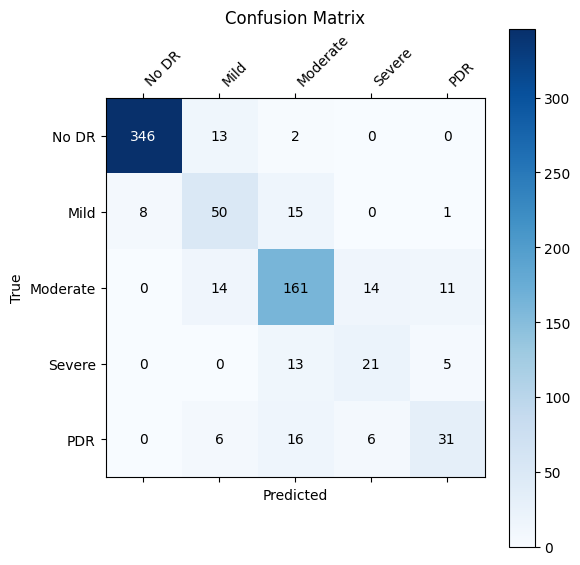

In [10]:
import matplotlib.pyplot as plt

TTA_TRANSFORMS = [
    A.Compose([A.Normalize(), ToTensorV2()]),
    A.Compose([A.HorizontalFlip(p=1), A.Normalize(), ToTensorV2()]),
    A.Compose([A.VerticalFlip(p=1), A.Normalize(), ToTensorV2()]),
    A.Compose([A.RandomRotate90(p=1), A.Normalize(), ToTensorV2()]),
    A.Compose([A.Transpose(p=1), A.Normalize(), ToTensorV2()]),
    A.Compose([A.HorizontalFlip(p=1), A.VerticalFlip(p=1), A.Normalize(), ToTensorV2()]),
    A.Compose([A.ColorJitter(brightness=0.1, contrast=0.1, p=1), A.Normalize(), ToTensorV2()]),
    A.Compose([A.GaussianBlur(blur_limit=(3, 5), p=1), A.Normalize(), ToTensorV2()]),
]

# Load best checkpoint
ckpt  = torch.load(CFG['save_path'], map_location=DEVICE, weights_only=False)
model = DRDModel().to(DEVICE)
model.load_state_dict(ckpt['state'])
model.eval()

scores, y_true = None, None
with torch.no_grad():
    for i, tf in enumerate(TTA_TRANSFORMS):
        print(f"TTA {i+1}/{len(TTA_TRANSFORMS)}...")
        loader = DataLoader(DRDataset(val_df, tf), batch_size=CFG['batch_size'] * 2,
                            shuffle=False, num_workers=2)
        probs, labs = [], []
        for imgs, lbls in loader:
            probs.append(F.softmax(model(imgs.to(DEVICE)), dim=-1).cpu().numpy())
            if i == 0:
                labs.extend(lbls.numpy())
        if i == 0:
            y_true = np.array(labs)
        sc = np.vstack(probs)
        scores = sc if scores is None else scores + sc

y_pred = (scores / len(TTA_TRANSFORMS)).argmax(1)
kappa  = cohen_kappa_score(y_true, y_pred, weights='quadratic')
acc    = accuracy_score(y_true, y_pred)

CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'PDR']
print(f"\nTTA Kappa: {kappa:.4f} | Accuracy: {acc*100:.2f}%")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm  = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 6))
cax = ax.matshow(cm, cmap='Blues')
fig.colorbar(cax)
ax.set_xticks(range(5)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='left')
ax.set_yticks(range(5)); ax.set_yticklabels(CLASS_NAMES)
for (i, j), z in np.ndenumerate(cm):
    ax.text(j, i, str(z), ha='center', va='center',
            color='white' if z > cm.max() / 2 else 'black')
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

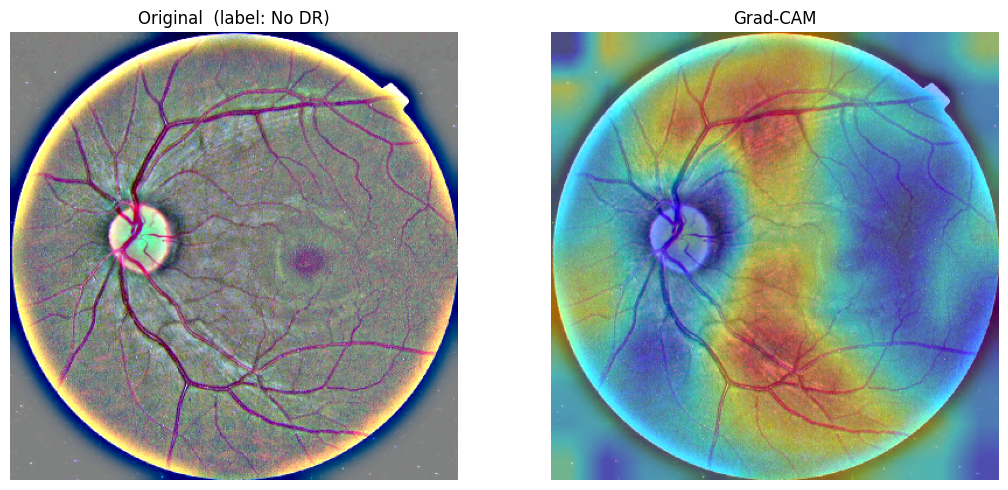

In [11]:
class GradCAM:
    def __init__(self, model, layer):
        self.grads = self.acts = None
        layer.register_forward_hook(lambda m, i, o: setattr(self, 'acts', o.detach()))
        layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def __call__(self, x, cls):
        model.zero_grad()
        model(x)[0, cls].backward(retain_graph=True)
        w   = self.grads.mean(dim=[0, 2, 3])
        cam = (self.acts[0] * w[:, None, None]).mean(0).relu().cpu().numpy()
        cam = cam / (cam.max() + 1e-8)
        return cam


# Target the last conv block's bn2 -- stable across EfficientNet variants
target_layer = model.cnn.blocks[-1][-1].bn2
gcam = GradCAM(model, target_layer)

sample_img, sample_lbl = DRDataset(val_df, val_tf)[0]
x   = sample_img.unsqueeze(0).to(DEVICE)
cam = gcam(x, sample_lbl)

# Denormalize for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_np = (sample_img.permute(1, 2, 0).numpy() * std + mean).clip(0, 1)
img_u8 = (img_np * 255).astype(np.uint8)

cam_r   = cv2.resize(cam, (img_u8.shape[1], img_u8.shape[0]))
overlay = cv2.addWeighted(img_u8, 0.6,
                          cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET), 0.4, 0)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(img_np);  ax[0].set_title(f'Original  (label: {CLASS_NAMES[sample_lbl]})')
ax[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); ax[1].set_title('Grad-CAM')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

In [12]:
from google.colab import files
try:
    files.download(CFG['save_path'])
except Exception as e:
    print(f"Auto-download failed: {e}. Download manually from the Files tab.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>